Importing Useful packages; Note these packages should be installed


1.   qiskit
2.   qiskit_ibm_runtime

Installation code :  !pip install qiskit





In [6]:
# Built-in modules
import math

# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Imports from Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import plot_histogram

In [187]:
qc = QuantumCircuit(4,3) # 4 qubits and 4 classical bits

Preapering Ancila


In [188]:
# Put qubit 3 into the |-> state for phase kickback
qc.x(3)
qc.h(3)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

Create Superposition

In [189]:
for i in range(3):
    qc.h(i)

Creating Oracle having the marked state as 5

In [190]:
def oracle(circuit):
    circuit.barrier()

    # Target = |101> -> Qubit indices: q2=1, q1=0, q0=1
    # Flip q1 so that the state |101> becomes |111> for the MCX gate
    circuit.x(1)

    # Multi-controlled X onto the ancilla qubit (qubit 3) triggers phase kickback
    circuit.mcx([0, 1, 2], 3)

    # Undo the X gate to restore the state
    circuit.x(1)

    circuit.barrier()

Diffusion Oporator

In [191]:
def diffusion(circuit):

    # Step 1: H gates
    for i in range(3):
        circuit.h(i)

    # Step 2: X gates
    for i in range(3):
        circuit.x(i)

    # Step 3: Multi-controlled Z on the working qubits
    # We turn an MCX into an MCZ by wrapping the target qubit (2) in Hadamards
    circuit.h(2)
    circuit.mcx([0, 1], 2)
    circuit.h(2)

    # Step 4: Undo X gates
    for i in range(3):
        circuit.x(i)

    # Step 5: Undo H gates
    for i in range(3):
        circuit.h(i)

    circuit.barrier()

In [192]:
N = 2**3
M = 1
repeat = round((math.pi / 4) * math.sqrt(N / M)) # Will equal 2 iterations

for _ in range(repeat):
    oracle(qc)
    diffusion(qc)

In [193]:
qc.measure([0, 1, 2], [0, 1, 2])

In [194]:
print(qc.draw("text"))

                ░ ┌───┐ ░                 ░ ┌───┐┌───┐                ░ ┌───┐»
q_0: ───────────░─┤ H ├─░────────■────────░─┤ H ├┤ X ├───────■────────░─┤ X ├»
                ░ ├───┤ ░ ┌───┐  │  ┌───┐ ░ ├───┤├───┤       │        ░ ├───┤»
q_1: ───────────░─┤ H ├─░─┤ X ├──■──┤ X ├─░─┤ H ├┤ X ├───────■────────░─┤ X ├»
                ░ ├───┤ ░ └───┘  │  └───┘ ░ ├───┤├───┤┌───┐┌─┴─┐┌───┐ ░ ├───┤»
q_2: ───────────░─┤ H ├─░────────■────────░─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─░─┤ X ├»
     ┌───┐┌───┐ ░ └───┘ ░      ┌─┴─┐      ░ └───┘└───┘└───┘└───┘└───┘ ░ └───┘»
q_3: ┤ X ├┤ H ├─░───────░──────┤ X ├──────░───────────────────────────░──────»
     └───┘└───┘ ░       ░      └───┘      ░                           ░      »
c: 3/════════════════════════════════════════════════════════════════════════»
                                                                             »
«     ┌───┐ ░  ░                 ░ ┌───┐┌───┐                ░ ┌───┐┌───┐ ░ ┌─┐»
«q_0: ┤ H ├─░──░────────■────────░─┤ H ├┤ X ├─────

Ploting the probabilities

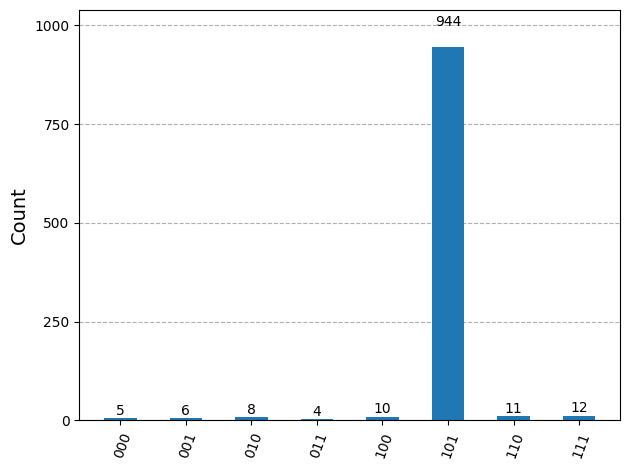

In [177]:
# 1. Run the job
sampler = Sampler()
job = sampler.run([qc], shots=1000)
result = job.result()

# 2. Get the result for your circuit
pub_result = result[0]

# 3. Extract the counts dictionary
counts = pub_result.data.c.get_counts()

# 4. Pass the counts directly to Qiskit's automatic plotter
plot_histogram(counts)